In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv


In [4]:
# Cell 1 — Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Load the data — use the Year 2010-2011 sheet
df = pd.read_csv('/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (1067371, 8)

Column Names:
 ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types:
 Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085.000,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.000,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.000,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085.000,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085.000,United Kingdom


In [5]:
# Cell 2 — EDA: Understanding Missing Values, Cancellations & Basic Stats

print("="*50)
print("NULL VALUE ANALYSIS")
print("="*50)
print(df.isnull().sum())
print("\nNull % per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\n" + "="*50)
print("CANCELLED ORDERS ANALYSIS")
print("="*50)
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"Total cancelled transactions: {len(cancelled)}")
print(f"Cancelled % of total data: {(len(cancelled)/len(df)*100):.2f}%")

print("\n" + "="*50)
print("NEGATIVE VALUES CHECK")
print("="*50)
print(f"Rows with negative Quantity: {(df['Quantity'] < 0).sum()}")
print(f"Rows with negative Price: {(df['Price'] < 0).sum()}")
print(f"Rows with zero Price: {(df['Price'] == 0).sum()}")

print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df[['Quantity', 'Price']].describe())

print("\n" + "="*50)
print("UNIQUE COUNTS")
print("="*50)
print(f"Unique Customers: {df['Customer ID'].nunique()}")
print(f"Unique Countries: {df['Country'].nunique()}")
print(f"Unique Invoices: {df['Invoice'].nunique()}")
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

NULL VALUE ANALYSIS
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Null % per column:
Invoice        0.000
StockCode      0.000
Description    0.410
Quantity       0.000
InvoiceDate    0.000
Price          0.000
Customer ID   22.770
Country        0.000
dtype: float64

CANCELLED ORDERS ANALYSIS
Total cancelled transactions: 19494
Cancelled % of total data: 1.83%

NEGATIVE VALUES CHECK
Rows with negative Quantity: 22950
Rows with negative Price: 5
Rows with zero Price: 6202

BASIC STATISTICS
         Quantity       Price
count 1067371.000 1067371.000
mean        9.939       4.649
std       172.706     123.553
min    -80995.000  -53594.360
25%         1.000       1.250
50%         3.000       2.100
75%        10.000       4.150
max     80995.000   38970.000

UNIQUE COUNTS
Unique Customers: 5942
Unique Countries: 43
Unique Invoices: 53628
Date Rang

In [6]:
# Cell 3 — Data Cleaning

print(f"Shape before cleaning: {df.shape}")

# Step 1: Drop rows with missing Customer ID
df = df.dropna(subset=['Customer ID'])
print(f"After dropping null Customer IDs: {df.shape}")

# Step 2: Remove cancelled orders (Invoice starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

# Step 3: Remove negative or zero Quantity
df = df[df['Quantity'] > 0]
print(f"After removing negative/zero Quantity: {df.shape}")

# Step 4: Remove negative or zero Price
df = df[df['Price'] > 0]
print(f"After removing negative/zero Price: {df.shape}")

# Step 5: Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Step 6: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 7: Create a TotalPrice column (Quantity x Price)
df['TotalPrice'] = df['Quantity'] * df['Price']

print(f"\nFinal clean shape: {df.shape}")
print(f"\nData types after cleaning:")
print(df.dtypes)
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"\nUnique customers remaining: {df['Customer ID'].nunique()}")
df.head()

Shape before cleaning: (1067371, 8)
After dropping null Customer IDs: (824364, 8)
After removing cancellations: (805620, 8)
After removing negative/zero Quantity: (805620, 8)
After removing negative/zero Price: (805549, 8)

Final clean shape: (805549, 9)

Data types after cleaning:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
TotalPrice            float64
dtype: object

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Unique customers remaining: 5878


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085,United Kingdom,83.400
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085,United Kingdom,100.800
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085,United Kingdom,30.000


In [7]:
# Cell 4 — RFM Feature Engineering

# Reference date = 1 day after the last transaction in dataset
# (simulating "today" from the data's perspective)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# Build RFM table — one row per customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"\nRFM Table Shape: {rfm.shape}")
print(f"\nFirst 5 rows:")
print(rfm.head())

print(f"\nRFM Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# Check for any anomalies
print(f"\nAny nulls in RFM? {rfm.isnull().sum().sum()}")
print(f"Customers with Monetary <= 0: {(rfm['Monetary'] <= 0).sum()}")

Reference date: 2011-12-10 12:50:00

RFM Table Shape: (5878, 4)

First 5 rows:
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12 77556.460
1        12347        2          8  5633.320
2        12348       75          5  2019.400
3        12349       19          4  4428.690
4        12350      310          1   334.400

RFM Statistics:
       Recency  Frequency   Monetary
count 5878.000   5878.000   5878.000
mean   201.332      6.289   3018.617
std    209.339     13.009  14737.731
min      1.000      1.000      2.950
25%     26.000      1.000    348.762
50%     96.000      3.000    898.915
75%    380.000      7.000   2307.090
max    739.000    398.000 608821.650

Any nulls in RFM? 0
Customers with Monetary <= 0: 0


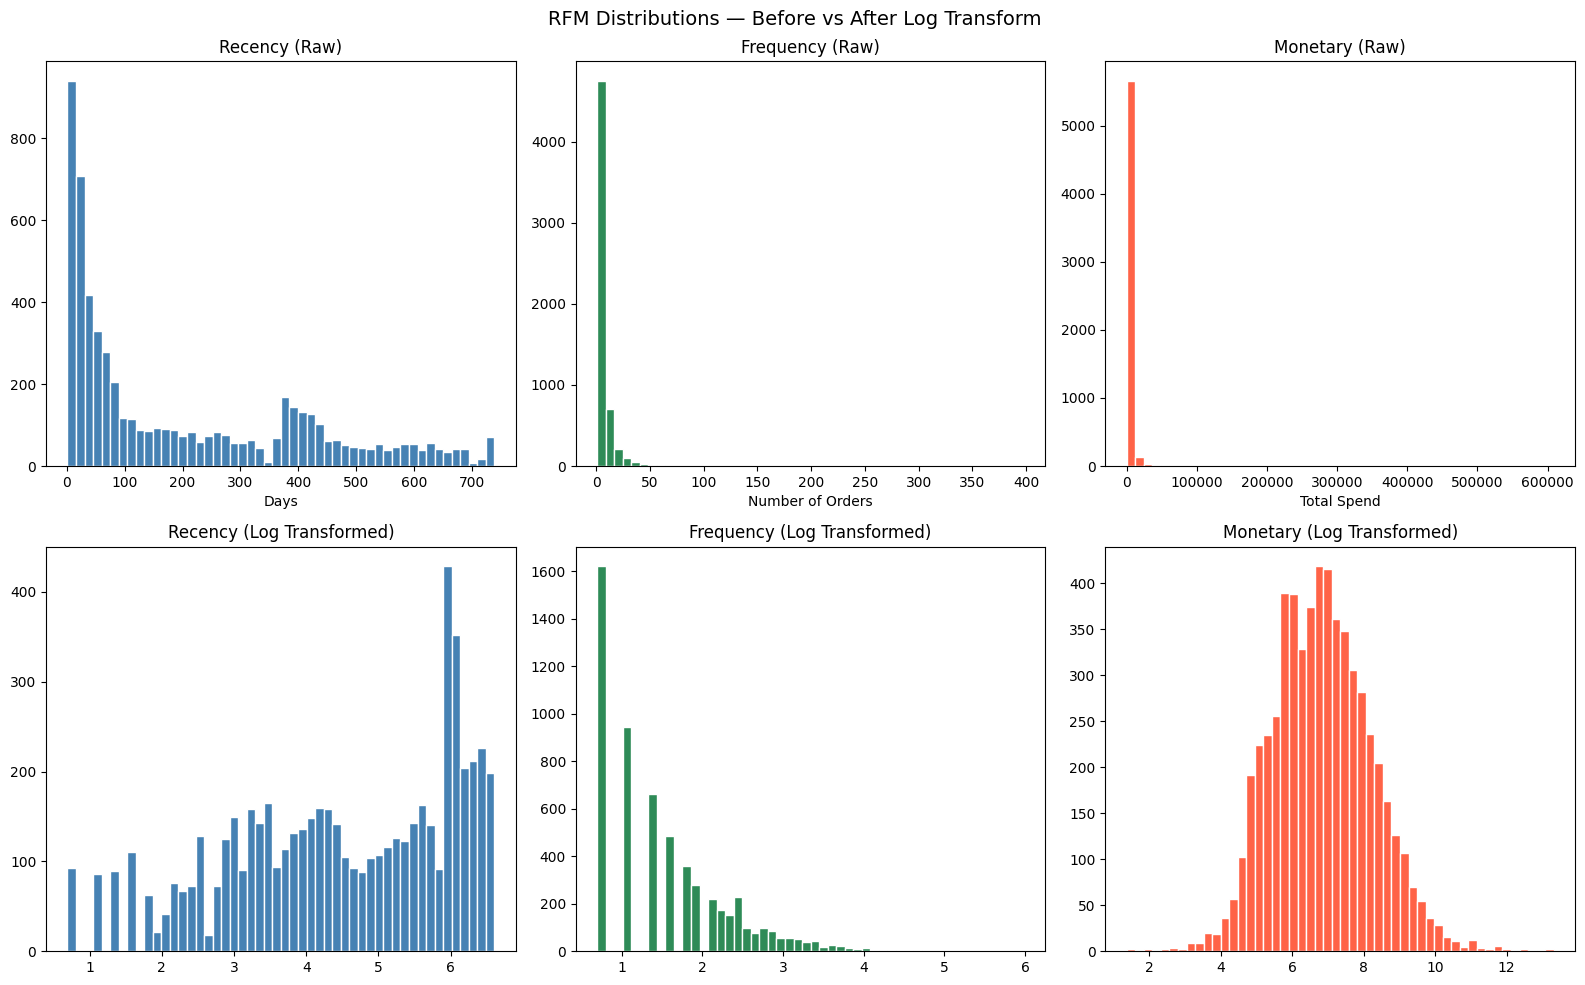

Skewness BEFORE log transform:
  Recency:   0.887
  Frequency: 12.640
  Monetary:  25.314

Skewness AFTER log transform:
  Recency:   -0.489
  Frequency: 1.001
  Monetary:  0.265


In [8]:
# Cell 5 — RFM Distribution Plots (Understanding Skewness)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('RFM Distributions — Before vs After Log Transform', fontsize=14)

# --- Row 1: Raw distributions ---
axes[0, 0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Recency (Raw)')
axes[0, 0].set_xlabel('Days')

axes[0, 1].hist(rfm['Frequency'], bins=50, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Frequency (Raw)')
axes[0, 1].set_xlabel('Number of Orders')

axes[0, 2].hist(rfm['Monetary'], bins=50, color='tomato', edgecolor='white')
axes[0, 2].set_title('Monetary (Raw)')
axes[0, 2].set_xlabel('Total Spend')

# --- Row 2: Log-transformed distributions ---
axes[1, 0].hist(np.log1p(rfm['Recency']), bins=50, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Recency (Log Transformed)')

axes[1, 1].hist(np.log1p(rfm['Frequency']), bins=50, color='seagreen', edgecolor='white')
axes[1, 1].set_title('Frequency (Log Transformed)')

axes[1, 2].hist(np.log1p(rfm['Monetary']), bins=50, color='tomato', edgecolor='white')
axes[1, 2].set_title('Monetary (Log Transformed)')

plt.tight_layout()
plt.show()

# Print skewness values
print("Skewness BEFORE log transform:")
print(f"  Recency:   {rfm['Recency'].skew():.3f}")
print(f"  Frequency: {rfm['Frequency'].skew():.3f}")
print(f"  Monetary:  {rfm['Monetary'].skew():.3f}")

print("\nSkewness AFTER log transform:")
print(f"  Recency:   {np.log1p(rfm['Recency']).skew():.3f}")
print(f"  Frequency: {np.log1p(rfm['Frequency']).skew():.3f}")
print(f"  Monetary:  {np.log1p(rfm['Monetary']).skew():.3f}")

In [9]:
# Cell 6 — Log Transform + StandardScaler

from sklearn.preprocessing import StandardScaler

# Step 1: Apply log1p transformation to reduce skewness
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

# Step 2: StandardScaler — mean=0, std=1 for each feature
# This ensures no single feature dominates Euclidean distance
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert back to DataFrame for readability
rfm_scaled_df = pd.DataFrame(rfm_scaled, 
                              columns=['Recency', 'Frequency', 'Monetary'])

print("After Scaling — Statistics (should be ~mean=0, std=1):")
print(rfm_scaled_df.describe().round(3))

print(f"\nShape of scaled data: {rfm_scaled_df.shape}")
print("\nFirst 5 rows of scaled data:")
print(rfm_scaled_df.head())

After Scaling — Statistics (should be ~mean=0, std=1):
       Recency  Frequency  Monetary
count 5878.000   5878.000  5878.000
mean    -0.000      0.000    -0.000
std      1.000      1.000     1.000
min     -2.412     -1.058    -3.936
25%     -0.743     -1.058    -0.706
50%      0.077     -0.202    -0.025
75%      0.955      0.655     0.654
max      1.380      5.485     4.671

Shape of scaled data: (5878, 3)

First 5 rows of scaled data:
   Recency  Frequency  Monetary
0    0.857      1.254     3.187
1   -2.152      0.800     1.297
2   -0.079      0.299     0.558
3   -0.935      0.074     1.124
4    0.825     -1.058    -0.736


Testing K values...
  K=2 | Inertia: 8588.81 | Silhouette: 0.4343
  K=3 | Inertia: 6351.98 | Silhouette: 0.3458
  K=4 | Inertia: 4918.64 | Silhouette: 0.3649
  K=5 | Inertia: 4097.83 | Silhouette: 0.3462
  K=6 | Inertia: 3552.98 | Silhouette: 0.3354
  K=7 | Inertia: 3184.84 | Silhouette: 0.3075
  K=8 | Inertia: 2891.60 | Silhouette: 0.2925
  K=9 | Inertia: 2650.60 | Silhouette: 0.2864
  K=10 | Inertia: 2455.91 | Silhouette: 0.2856


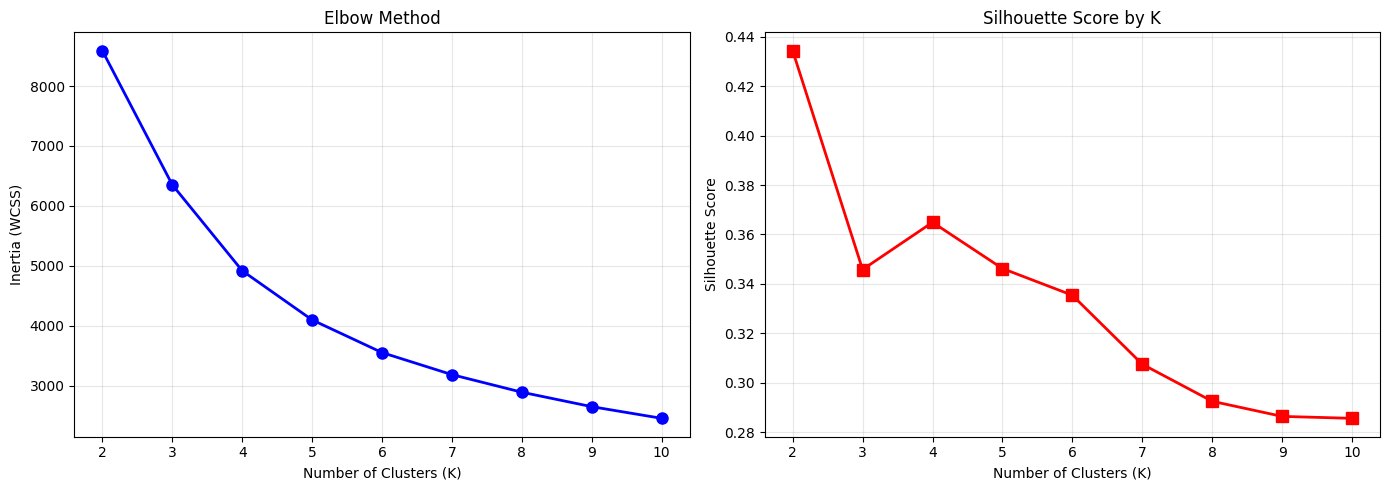

In [10]:
# Cell 7 — Elbow Method + Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 11)

print("Testing K values...")
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(rfm_scaled, km.labels_, sample_size=2000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  K={k} | Inertia: {km.inertia_:.2f} | Silhouette: {sil:.4f}")

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette Plot
axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cluster distribution:
Cluster
0    1188
1    1974
2    1465
3    1251
Name: count, dtype: int64

Cluster %:
Cluster
0   20.210
1   33.580
2   24.920
3   21.280
Name: proportion, dtype: float64

--- Cluster Profiles (Original RFM Values) ---
         Recency  Frequency  Monetary
Cluster                              
0         27.430     19.340 11014.370
1        395.860      1.380   325.750
2        227.870      5.100  2002.100
3         28.440      3.040   865.110


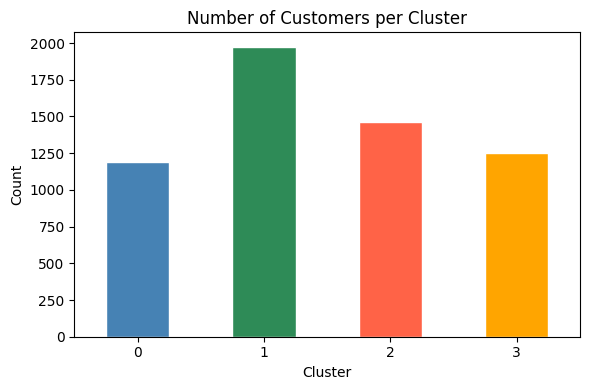

In [11]:
# Cell 8 — Train Final K-Means with K=4

from sklearn.cluster import KMeans

# Train final model
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
kmeans.fit(rfm_scaled)

# Assign cluster labels back to original RFM dataframe
rfm['Cluster'] = kmeans.labels_

print("Cluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())
print(f"\nCluster %:")
print((rfm['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

# Cluster profiling — mean of ORIGINAL (unscaled) RFM values per cluster
print("\n--- Cluster Profiles (Original RFM Values) ---")
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_profile)

# Visualize cluster sizes
plt.figure(figsize=(6,4))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color=['steelblue','seagreen','tomato','orange'], edgecolor='white')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

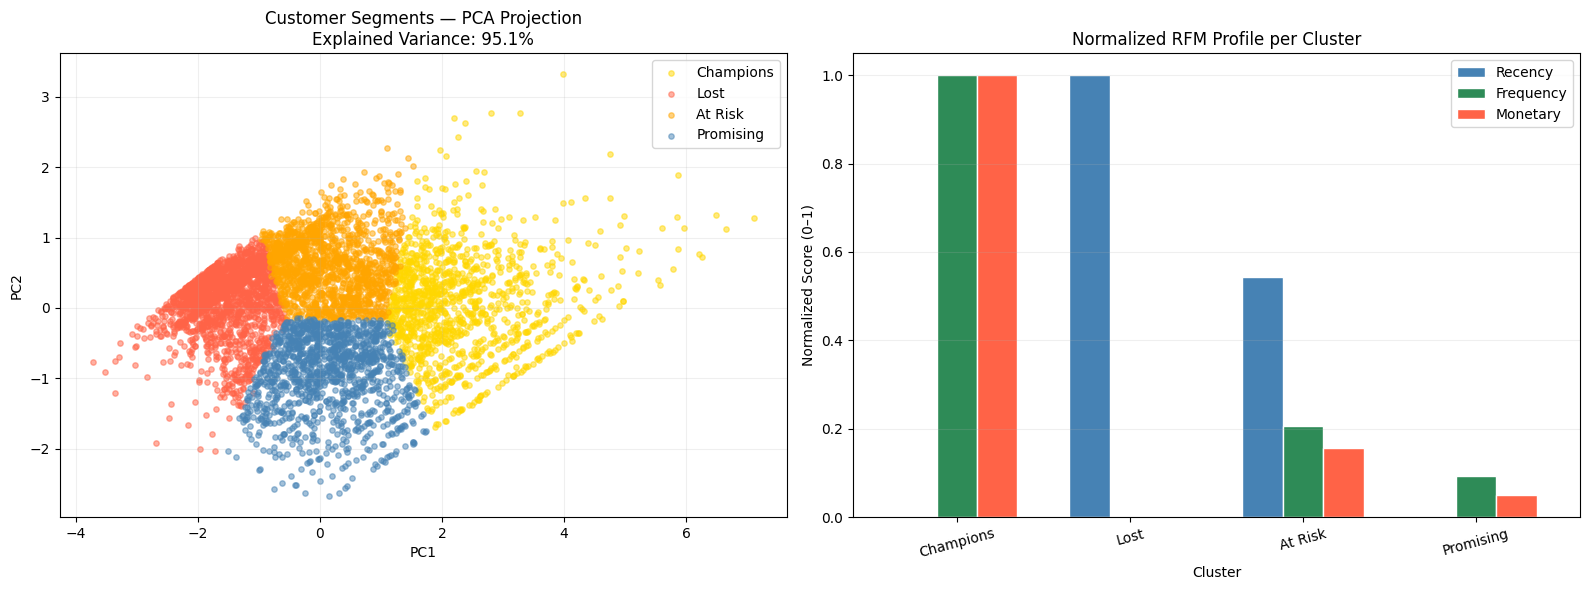

PCA Explained Variance: PC1=76.4%, PC2=18.8%


In [12]:
# Cell 9 — PCA Visualization + Cluster Radar Chart

from sklearn.decomposition import PCA

# --- Plot 1: PCA 2D Cluster Visualization ---
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(rfm_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster'].values

colors = {0: 'gold', 1: 'tomato', 2: 'orange', 3: 'steelblue'}
labels = {0: 'Champions', 1: 'Lost', 2: 'At Risk', 3: 'Promising'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA Scatter
for cluster in range(4):
    mask = pca_df['Cluster'] == cluster
    axes[0].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
                    c=colors[cluster], label=labels[cluster],
                    alpha=0.5, s=15)
axes[0].set_title(f'Customer Segments — PCA Projection\n'
                  f'Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# --- Plot 2: Cluster Profile Bar Chart ---
profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
profile.index = [labels[i] for i in profile.index]

# Normalize for comparison (min-max)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

profile_norm.plot(kind='bar', ax=axes[1], 
                  color=['steelblue', 'seagreen', 'tomato'],
                  edgecolor='white', width=0.7)
axes[1].set_title('Normalized RFM Profile per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Normalized Score (0–1)')
axes[1].legend(['Recency', 'Frequency', 'Monetary'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

print(f"PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

In [13]:
# Cell 10 — Business Recommendations Summary

recommendations = {
    'Champions':  'Reward them. Ask for reviews. Offer early access to new products.',
    'Lost':       'Send win-back campaigns. Offer heavy discounts. Last attempt before archiving.',
    'At Risk':    'Send personalized emails. Offer limited-time deals to re-engage.',
    'Promising':  'Onboard properly. Build loyalty with small incentives and follow-ups.'
}

print("="*60)
print("CUSTOMER SEGMENT STRATEGY")
print("="*60)
summary = rfm.groupby('Cluster').agg(
    Segment_Name  = ('Cluster', lambda x: labels[x.iloc[0]]),
    Customer_Count= ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(2)

print(summary)
print("\nBusiness Actions:")
for seg, action in recommendations.items():
    print(f"\n  [{seg}]\n  → {action}")

CUSTOMER SEGMENT STRATEGY
        Segment_Name  Customer_Count  Avg_Recency  Avg_Frequency  \
Cluster                                                            
0          Champions            1188       27.430         19.340   
1               Lost            1974      395.860          1.380   
2            At Risk            1465      227.870          5.100   
3          Promising            1251       28.440          3.040   

         Avg_Monetary  Total_Revenue  
Cluster                               
0           11014.370   13085069.690  
1             325.750     643026.910  
2            2002.100    2933080.130  
3             865.110    1082252.450  

Business Actions:

  [Champions]
  → Reward them. Ask for reviews. Offer early access to new products.

  [Lost]
  → Send win-back campaigns. Offer heavy discounts. Last attempt before archiving.

  [At Risk]
  → Send personalized emails. Offer limited-time deals to re-engage.

  [Promising]
  → Onboard properly. Build loyalty w